## Gaussian NB

In [1]:
import numpy as np

class MyGaussianNB:
    def fit(self, X, y):
        self.classes=np.unique(y)
        self.mean={}
        self.var={}
        self.priors={}
        
        for c in self.classes:
            X_c=X[y==c]
            self.mean[c]=X_c.mean(axis=0)
            self.var[c]=X_c.var(axis=0)+1e-9
            self.priors[c]=X_c.shape[0]/X.shape[0]
            
    def _gaussian_prob(self, x, mean, var):
        numerator=np.exp(-((x-mean)**2)/(2*var))
        denomitor=np.sqrt(2*np.pi*var)
        return numerator/denomitor
    
    def predict_proba(self, X):
        probs=[]
        
        for x in X:
            class_probs=[]
            
            for c in self.classes:
                prior=np.log(self.priors[c])
                conditional=np.sum(
                    np.log(self._gaussian_prob(x, self.mean[c], self.var[c]))
                )
                class_probs.append(prior+conditional)
                
            probs.append(class_probs)
            
        return np.array(probs)
    
    def predict(self, X):
        probs=self.predict_proba(X)
        return self.classes[np.argmax(probs, axis=1)]

## Multinomial Naive Bayes 

In [2]:
class MyMultinomialNB:
    def fit(self, X, y):
        self.classes=np.unique(y)
        self.feature_count={}
        self.class_count={}
        self.feature_prob={}
        
        for c in self.classes:
            X_c=X[y==c]
            self.feature_count[c]=X_c.sum(axis=0)
            self.class_count[c]=X_c.sum()
            
        self.vocab_size=X.shape[1]
        
        for c in self.classes:
            self.feature_prob[c]=(
                (self.feature_count[c]+1)/
                (self.class_count[c]+self.vocab_size)
            )
            
        self.priors={
            c:np.sum(y==c)/len(y) for c in self.class_count
        }
        
    def predict_proba(self, X):
        probs=[]
        
        for x in X:
            class_probs=[]
            
            for c in self.classes:
                log_prior=np.log(self.priors[c])
                log_likelihood=np.sum(x*np.log(self.feature_prob[c]))
                class_probs.append(log_prior+log_likelihood)
                
            probs.append(class_probs)
            
        return np.array(probs)
    
    def predict(self,X):
        probs=self.predict_proba(X)
        return self.classes[np.argmax(probs, axis=1)]
    

##  Bernoulli Naive Bayes

In [3]:
class MyBernoulliNB:
    def fit(self, X, y):
        self.classes=np.unique(y)
        self.feature_prob={}
        self.priors={}
        
        for c in self.classes:
            X_c=X[y==c]
            
            self.feature_prob[c]=(X_c.sum(axis=0)+1)/(X_c.shape[0]+2)
            
            self.priors[c]=X_c.shape[0]/X.shape[0]
            
    def predict_proba(self, X):
        probs=[]
        
        for x in X:
            class_probs=[]
            
            for c in self.classes:
                p=self.feature_prob[c]
                
                log_prior=np.log(self.priors[c])
                log_likelihood=np.sum(
                    x*np.log(p)+(1-x)*np.log(1-p)
                )
                
                class_probs.append(log_prior+log_likelihood)
                
            probs.append(class_probs)
            
        return np.array(probs)
    
    def predict(self, X):
        probs=self.predict_proba(X)
        return self.classes[np.argmax(probs, axis=1)]
    

## Implementation

In [4]:
import pandas as pd 
import numpy as np


url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
data=pd.read_csv(url)

# Basic cleaning
data = data[['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'SibSp', 'Parch']]
data = data.dropna()

#Encode
data["Sex"]=data["Sex"].map({"male":0, "female":1})
data=pd.get_dummies(data, columns=["Pclass"])

y=data["Survived"].values

In [5]:
# Gaussian (continous)
X_gaussian=data[["Age", "Fare"]].values

# Bernouli (Binary)
X_bernoulli=data[["Sex", "Pclass_1", "Pclass_2", "Pclass_3"]].values
X_bernoulli=(X_bernoulli>0).astype(int)

# Multinomial (counts)
X_multinomial=data[["SibSp", "Parch"]].values

In [6]:
# Train/Test Split

from sklearn.model_selection import train_test_split

Xg_train, Xg_test, y_train, y_test=train_test_split(
    X_gaussian, y, test_size=0.3, random_state=42
)

Xb_train, Xb_test, _, _=train_test_split(
    X_bernoulli, y, test_size=0.3, random_state=42
)

Xm_train, Xm_test, _, _=train_test_split(
    X_multinomial, y, test_size=0.3, random_state=42 
)

In [7]:
# Train the models

g_model=MyGaussianNB()
b_model=MyBernoulliNB()
m_model=MyMultinomialNB()

g_model.fit(Xg_train, y_train)
b_model.fit(Xb_train, y_train)
m_model.fit(Xm_train, y_train)

yg_pred=g_model.predict(Xg_test)
yb_pred=b_model.predict(Xb_test)
ym_pred=m_model.predict(Xm_test)

# Evaluation

In [8]:
from sklearn.metrics import accuracy_score

acc_g = accuracy_score(y_test, yg_pred)
acc_b = accuracy_score(y_test, yb_pred)
acc_m = accuracy_score(y_test, ym_pred)

print("Gaussian NB:", acc_g)
print("Bernoulli NB:", acc_b)
print("Multinomial NB:", acc_m)

Gaussian NB: 0.641860465116279
Bernoulli NB: 0.7627906976744186
Multinomial NB: 0.5813953488372093


# Visualization (Accuracy Comparison)

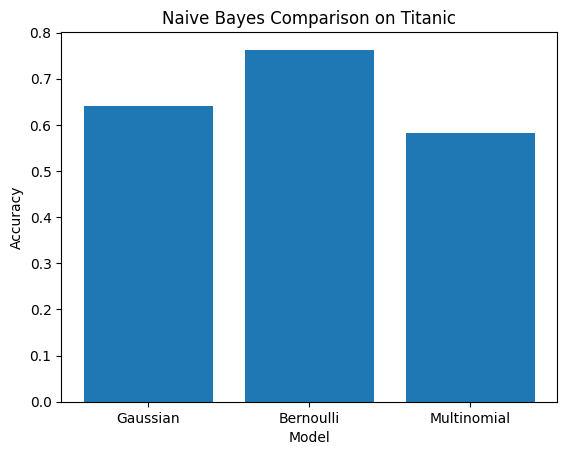

In [9]:
import matplotlib.pyplot as plt

models=["Gaussian", "Bernoulli", "Multinomial"]
accuracies=[acc_g, acc_b, acc_m]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Naive Bayes Comparison on Titanic")
plt.show()


## Confusion Matrix Visualization

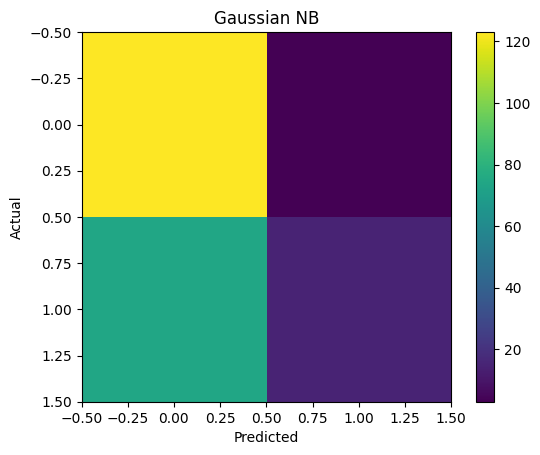

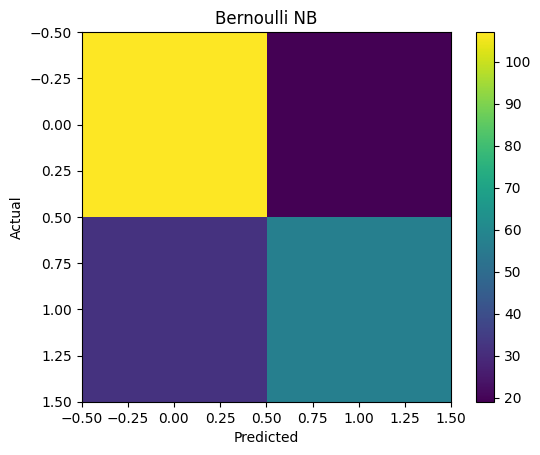

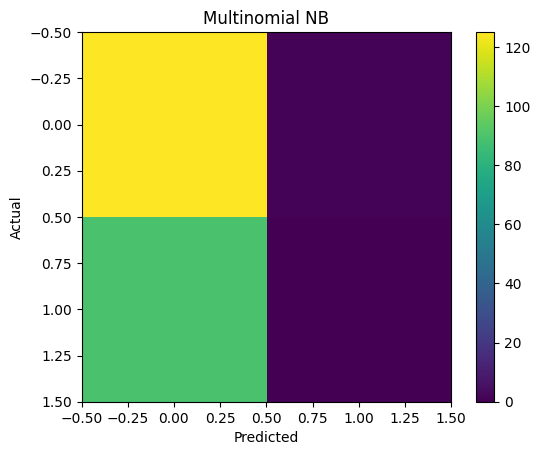

In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

def plot_cm(cm, title):
    plt.figure()
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.colorbar()
    plt.show()
    
plot_cm(confusion_matrix(y_test, yg_pred), "Gaussian NB")
plot_cm(confusion_matrix(y_test, yb_pred), "Bernoulli NB")
plot_cm(confusion_matrix(y_test, ym_pred), "Multinomial NB")